# 03 — Explainability Analysis

This notebook is the **thesis centerpiece**: three independent XAI methods applied to all four models, demonstrating explanation consistency across techniques.

**Three XAI methods used:**

| Method | How it works | Output |
|---|---|---|
| **SHAP** (TreeSHAP) | Game-theory: computes each feature's exact contribution to each prediction | Beeswarm (global), Waterfall (per-patient) |
| **LIME** | Builds a local linear model around each patient to approximate the complex model | Bar chart (per-patient), aggregated global ranking |
| **Permutation importance** | Shuffles each feature and measures how much worse the model gets | Bar chart (global) |

**Why three methods?** If all three agree on which features matter, the explanation is robust and trustworthy. If they disagree, it reveals which aspects of the model each method captures.

**Two example patients for local explanations:**
- **Short stay** (~1-2 days): typical ICU patient discharged quickly
- **Long stay** (~10-15 days): complex patient requiring extended care

**Sections:**
1. XGBoost — best classifier (AUC-PR 0.462), near-best regressor (MAE 2.169 d)
2. LightGBM — best regressor (MAE 2.168 d)
3. Random Forest — bagging vs boosting comparison
4. Linear (Ridge) — interpretable baseline
5. Cross-method agreement — do the three methods agree?
6. Classification task XAI — do the same features matter for binary prediction?
7. Clinical alignment — do our findings match ICU literature?
8. Feature group analysis — vital signs vs labs vs missing indicators

In [1]:
# ── Setup ──
SOURCE = "mimic4"
TASK = "regression"          # primary task for XAI
N_SHAP = 500                 # samples for SHAP global
N_LIME = 200                 # samples for LIME global aggregation
SEED = 42

import sys, warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import lime.lime_tabular
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

from src.config import FIGURES_DIR, MODELS_DIR, RANDOM_SEED, TARGET
from src.data.load import load_icu_stays
from src.features.build import split_xy
from src.models.train import prepare_target, to_days

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

# Load data + split (same split as training: seed=42, 80/20)
df = load_icu_stays(SOURCE)
X, y_raw, numeric_cols, categorical_cols = split_xy(df)
y = prepare_target(y_raw, TASK)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED,
)

# Load all 4 regression pipelines
MODELS = ["xgb", "lgbm", "rf", "linear"]
pipes = {}
for m in MODELS:
    p = MODELS_DIR / f"{m}_{TASK}_{SOURCE}.joblib"
    pipes[m] = joblib.load(p)
    print(f"Loaded {p.name}")

# Preprocess test set once (shared across all models since same preprocessor)
preprocessor = pipes["xgb"].named_steps["preprocess"]
X_te_trans = preprocessor.transform(X_te)
feature_names = list(preprocessor.get_feature_names_out())
print(f"\nTest set: {X_te_trans.shape[0]} samples x {X_te_trans.shape[1]} features")

Loaded xgb_regression_mimic4.joblib
Loaded lgbm_regression_mimic4.joblib
Loaded rf_regression_mimic4.joblib
Loaded linear_regression_mimic4.joblib



Test set: 9645 samples x 198 features


In [2]:
# ── Select 2 example patients for local explanations ──
# Short stay: represents a typical quick-discharge ICU patient
# Long stay: represents a complex patient needing extended care
y_te_days = to_days(y_te, TASK)
best_pipe = pipes["xgb"]
preds_days = to_days(best_pipe.predict(X_te), TASK)
err = np.abs(y_te_days.values - preds_days)

# Short stay: LoS 1-2 days, well-predicted (low error)
mask_short = (y_te_days.values >= 1) & (y_te_days.values <= 2)
idx_short = np.where(mask_short)[0][np.argmin(err[mask_short])]

# Long stay: LoS 10-20 days, well-predicted (low error)
mask_long = (y_te_days.values >= 10) & (y_te_days.values <= 20)
idx_long = np.where(mask_long)[0][np.argmin(err[mask_long])]

EXAMPLE_IDX = {"short_stay": idx_short, "long_stay": idx_long}

# Show all 4 models' predictions for each example patient
print("Example patients — actual LoS and each model's prediction:\n")
print(f"{'patient':>12s}  {'actual':>8s}  {'XGB':>8s}  {'LGBM':>8s}  {'RF':>8s}  {'Linear':>8s}")
print("-" * 62)
for label, idx in EXAMPLE_IDX.items():
    actual = y_te_days.values[idx]
    row = f"{label:>12s}  {actual:>7.1f}d"
    for m in MODELS:
        pred_d = to_days(pipes[m].predict(X_te.iloc[idx:idx+1]), TASK)[0]
        row += f"  {pred_d:>7.1f}d"
    print(row)

Example patients — actual LoS and each model's prediction:

     patient    actual       XGB      LGBM        RF    Linear
--------------------------------------------------------------


  short_stay      1.3d      1.3d      1.4d      1.6d      1.9d
   long_stay     10.9d     10.6d      9.7d      7.0d      5.1d


In [3]:
# ── Helper functions (reused across model sections) ──

def normalize_imp(imp_series, cat_cols=None):
    """Map transformed feature names back to raw column names.
    
    - 'num__age' -> 'age'
    - 'cat__gender_F' -> 'gender'  (all OHE dummies aggregated to base column)
    Permutation importance already uses raw names, so passthrough.
    """
    if cat_cols is None:
        cat_cols = categorical_cols
    result = {}
    for fname, val in imp_series.items():
        if fname.startswith("num__"):
            base = fname[5:]
        elif fname.startswith("cat__"):
            base = None
            for cc in cat_cols:
                if fname.startswith(f"cat__{cc}_"):
                    base = cc
                    break
            if base is None:
                base = fname[5:]
        else:
            base = fname
        result[base] = result.get(base, 0) + abs(val)
    return pd.Series(result).sort_values(ascending=False)


def shap_global(model_name, pipe, X_trans, feat_names, n_sample=N_SHAP):
    """SHAP beeswarm (global) for a tree model. Returns shap_values + mean |SHAP| Series."""
    estimator = pipe.named_steps["model"]
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_trans), size=min(n_sample, len(X_trans)), replace=False)
    X_sub = X_trans[idx]
    explainer = shap.TreeExplainer(estimator)
    sv = explainer(X_sub)
    sv.feature_names = feat_names
    shap.summary_plot(sv, X_sub, feature_names=feat_names, show=False, max_display=20)
    plt.title(f"SHAP beeswarm — {model_name} / {TASK}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_beeswarm_{model_name}_{TASK}_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()
    mean_abs = pd.Series(np.abs(sv.values).mean(axis=0), index=feat_names).sort_values(ascending=False)
    return sv, mean_abs


def shap_waterfall(model_name, pipe, X_trans, feat_names, example_idx, example_label):
    """SHAP waterfall for a single patient, with day-converted prediction in the title."""
    estimator = pipe.named_steps["model"]
    explainer = shap.TreeExplainer(estimator)
    sv = explainer(X_trans[example_idx:example_idx+1])
    sv.feature_names = feat_names
    # Convert log1p prediction to days for the title
    fx_log = sv[0].values.sum() + sv[0].base_values
    fx_days = np.expm1(fx_log)
    actual_days = y_te_days.values[example_idx]
    shap.waterfall_plot(sv[0], max_display=15, show=False)
    plt.title(
        f"SHAP waterfall — {model_name} / {example_label}\n"
        f"f(x)={fx_log:.3f} in log1p space = {fx_days:.1f} days  (actual={actual_days:.1f}d)",
        fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_waterfall_{model_name}_{example_label}_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()


def lime_explain(model_name, pipe, X_tr_trans, X_te_trans, feat_names, example_idx, example_label):
    """LIME explanation for a single patient. Returns feature importance dict."""
    predict_fn = lambda x: pipe.named_steps["model"].predict(x)
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_tr_trans, feature_names=feat_names, mode="regression",
        random_state=SEED, verbose=False,
    )
    exp = explainer.explain_instance(X_te_trans[example_idx], predict_fn, num_features=15)
    # Convert prediction to days for the title
    pred_log = pipe.named_steps["model"].predict(X_te_trans[example_idx:example_idx+1])[0]
    pred_days = np.expm1(pred_log)
    actual_days = y_te_days.values[example_idx]
    fig = exp.as_pyplot_figure()
    fig.suptitle(
        f"LIME — {model_name} / {example_label}  "
        f"(pred={pred_days:.1f}d, actual={actual_days:.1f}d)",
        fontsize=10,
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"lime_{model_name}_{example_label}_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return dict(exp.as_list())


def lime_global(model_name, pipe, X_tr_trans, X_te_trans, feat_names, n_sample=N_LIME):
    """Aggregate LIME over n_sample test instances for global feature ranking."""
    predict_fn = lambda x: pipe.named_steps["model"].predict(x)
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_tr_trans, feature_names=feat_names, mode="regression",
        random_state=SEED, verbose=False,
    )
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_te_trans), size=min(n_sample, len(X_te_trans)), replace=False)
    importances = pd.DataFrame(0.0, index=range(len(idx)), columns=feat_names)
    for i, ix in enumerate(idx):
        exp = explainer.explain_instance(X_te_trans[ix], predict_fn, num_features=len(feat_names))
        for feat, val in exp.as_list():
            for fn in feat_names:
                if fn in feat:
                    importances.loc[i, fn] = abs(val)
                    break
        if (i + 1) % 50 == 0:
            print(f"  LIME {model_name}: {i+1}/{len(idx)}")
    mean_imp = importances.mean().sort_values(ascending=False)
    print(f"  LIME {model_name}: done ({len(idx)} samples)")
    return mean_imp


def perm_importance(model_name, pipe, X_te_df, y_te_series):
    """Permutation importance on the held-out test set."""
    result = permutation_importance(
        pipe, X_te_df, y_te_series, n_repeats=10,
        random_state=SEED, scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    feat_cols = list(X_te_df.columns)
    imp = pd.Series(result.importances_mean, index=feat_cols).sort_values(ascending=False)
    top20 = imp.head(20)
    fig, ax = plt.subplots(figsize=(7, 6))
    top20[::-1].plot.barh(ax=ax, color="#3b6fb6")
    ax.set_xlabel("Mean MAE increase when permuted")
    ax.set_title(f"Permutation importance — {model_name} / {TASK}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"perm_importance_{model_name}_{TASK}_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return imp

## 1. XGBoost

Best classifier (AUC-PR 0.462) and near-best regressor (MAE 2.169 d). TreeSHAP provides exact Shapley values.

**What to look for in the plots below:**
- **SHAP beeswarm:** Each row = a feature. Each dot = a patient. Dot color = feature value (red = high, blue = low). Dot position on x-axis = how much that feature pushed the prediction up or down. Wide spread = high importance.
- **SHAP waterfall:** For one patient, shows how each feature pushed the prediction from the baseline (average) toward the final value. Red bars push the prediction higher (longer stay), blue bars push lower (shorter stay).
- **LIME:** Similar to waterfall but computed via a different method (local linear approximation). Green = shorter stay direction, red = longer stay.
- **Permutation importance:** When a feature is randomly shuffled, how much does the model's error increase? Taller bar = more important feature.

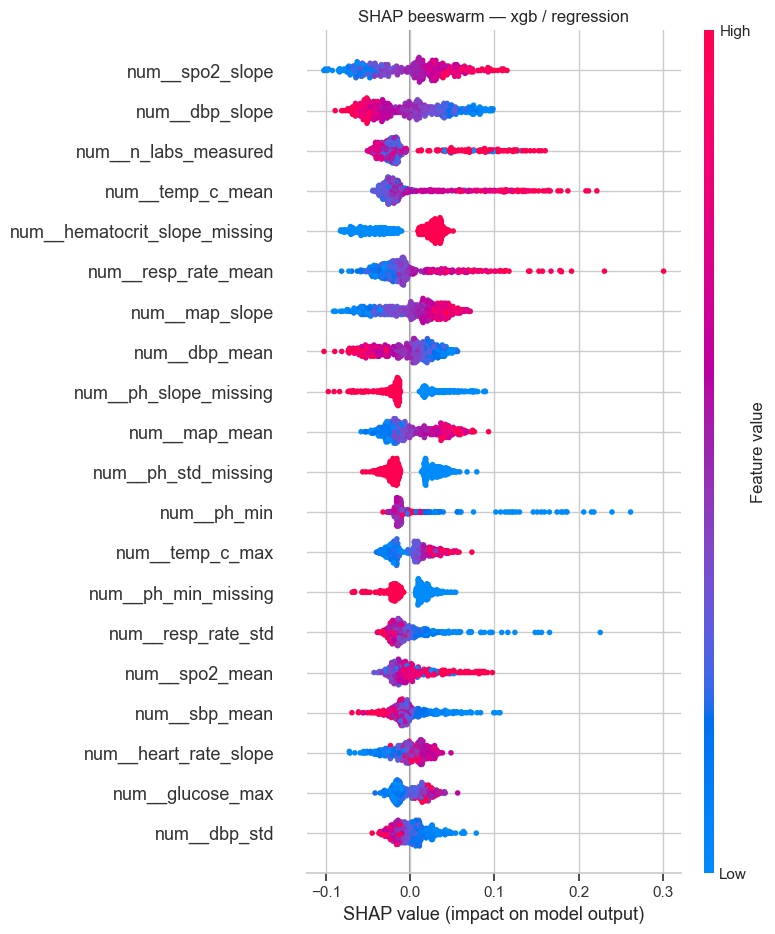


Top 10 features by mean |SHAP|:
num__spo2_slope                  0.040017
num__dbp_slope                   0.038521
num__n_labs_measured             0.037032
num__temp_c_mean                 0.036605
num__hematocrit_slope_missing    0.035447
num__resp_rate_mean              0.030995
num__map_slope                   0.030648
num__dbp_mean                    0.027524
num__ph_slope_missing            0.026818
num__map_mean                    0.026132


In [4]:
# ── XGB: SHAP global beeswarm ──
X_tr_trans = preprocessor.transform(X_tr)
xgb_sv, xgb_shap_imp = shap_global("xgb", pipes["xgb"], X_te_trans, feature_names)
print("\nTop 10 features by mean |SHAP|:")
print(xgb_shap_imp.head(10).to_string())


--- short_stay (actual=1.3d, pred=1.3d) ---


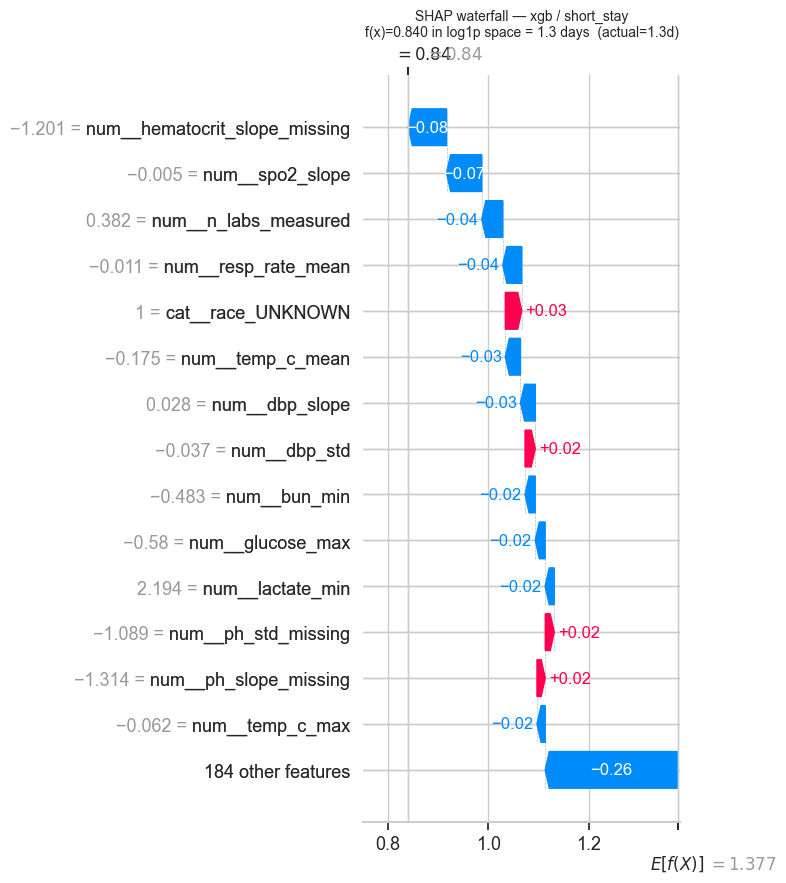


--- long_stay (actual=10.9d, pred=10.6d) ---


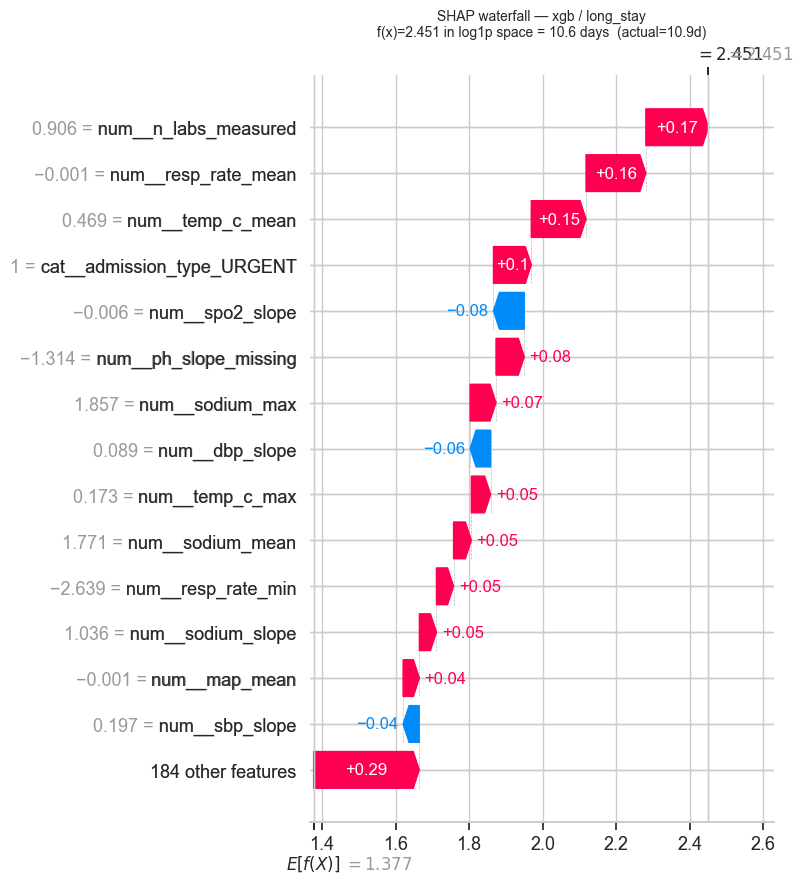

In [5]:
# ── XGB: SHAP waterfall for 3 example patients ──
for label, idx in EXAMPLE_IDX.items():
    print(f"\n--- {label} (actual={y_te_days.values[idx]:.1f}d, pred={preds_days[idx]:.1f}d) ---")
    shap_waterfall("xgb", pipes["xgb"], X_te_trans, feature_names, idx, label)


--- LIME: short_stay ---


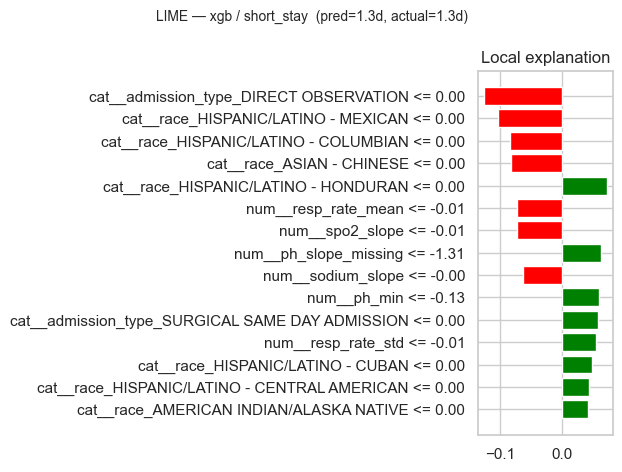


--- LIME: long_stay ---


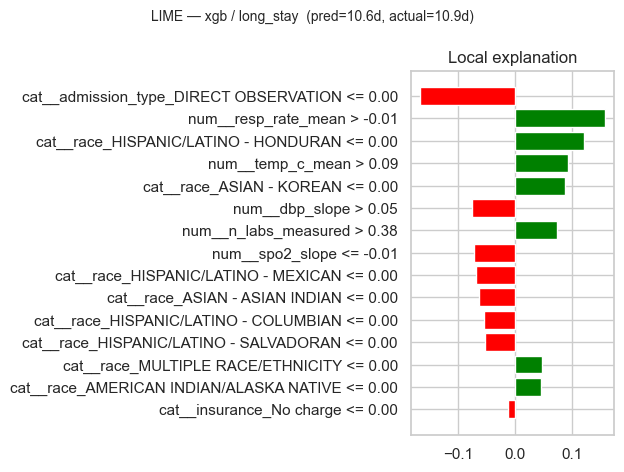

In [6]:
# ── XGB: LIME local for 3 patients ──
for label, idx in EXAMPLE_IDX.items():
    print(f"\n--- LIME: {label} ---")
    lime_explain("xgb", pipes["xgb"], X_tr_trans, X_te_trans, feature_names, idx, label)

In [7]:
# ── XGB: LIME global (aggregated over 200 samples) ──
xgb_lime_imp = lime_global("xgb", pipes["xgb"], X_tr_trans, X_te_trans, feature_names)

  LIME xgb: 50/200


  LIME xgb: 100/200


  LIME xgb: 150/200


  LIME xgb: 200/200
  LIME xgb: done (200 samples)


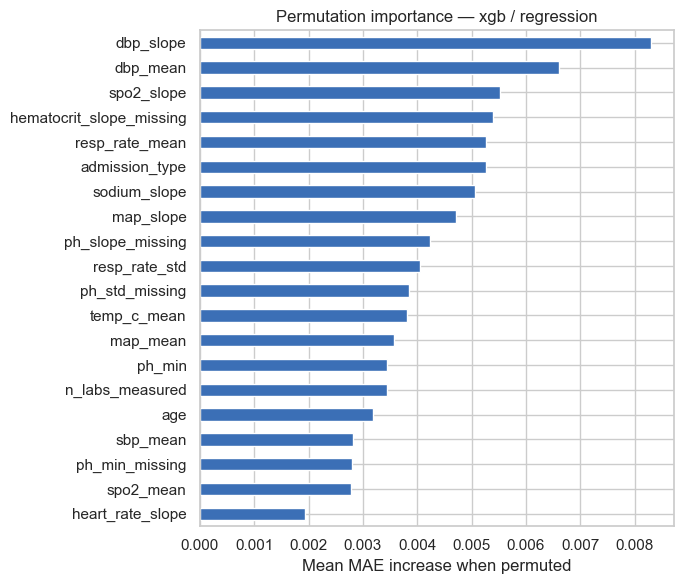

In [8]:
# ── XGB: Permutation importance ──
xgb_perm_imp = perm_importance("xgb", pipes["xgb"], X_te, y_te)

## 2. LightGBM

Best regressor (MAE 2.168 d). Similar gradient-boosting architecture to XGB. Key question: do two boosting models that achieve near-identical accuracy also produce the same explanations? If yes, the explanations are architecture-robust.

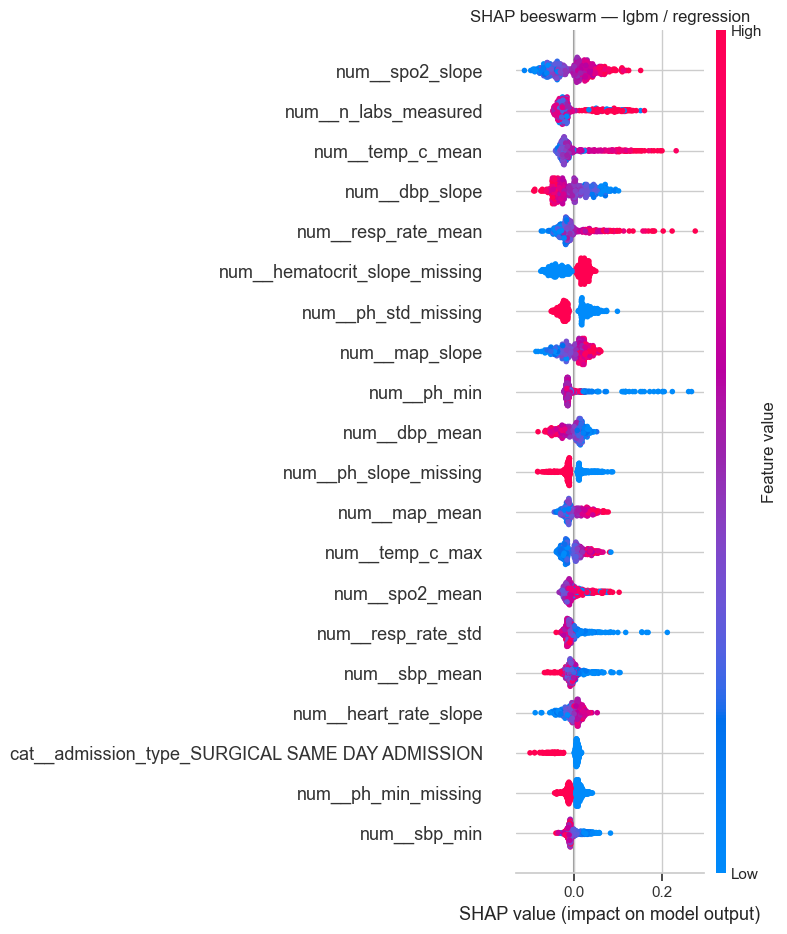


Top 10 features by mean |SHAP|:
num__spo2_slope                  0.041056
num__n_labs_measured             0.037322
num__temp_c_mean                 0.034627
num__dbp_slope                   0.033185
num__resp_rate_mean              0.029394
num__hematocrit_slope_missing    0.029356
num__ph_std_missing              0.027884
num__map_slope                   0.024032
num__ph_min                      0.021111
num__dbp_mean                    0.021103


In [9]:
lgbm_sv, lgbm_shap_imp = shap_global("lgbm", pipes["lgbm"], X_te_trans, feature_names)
print("\nTop 10 features by mean |SHAP|:")
print(lgbm_shap_imp.head(10).to_string())


--- short_stay ---


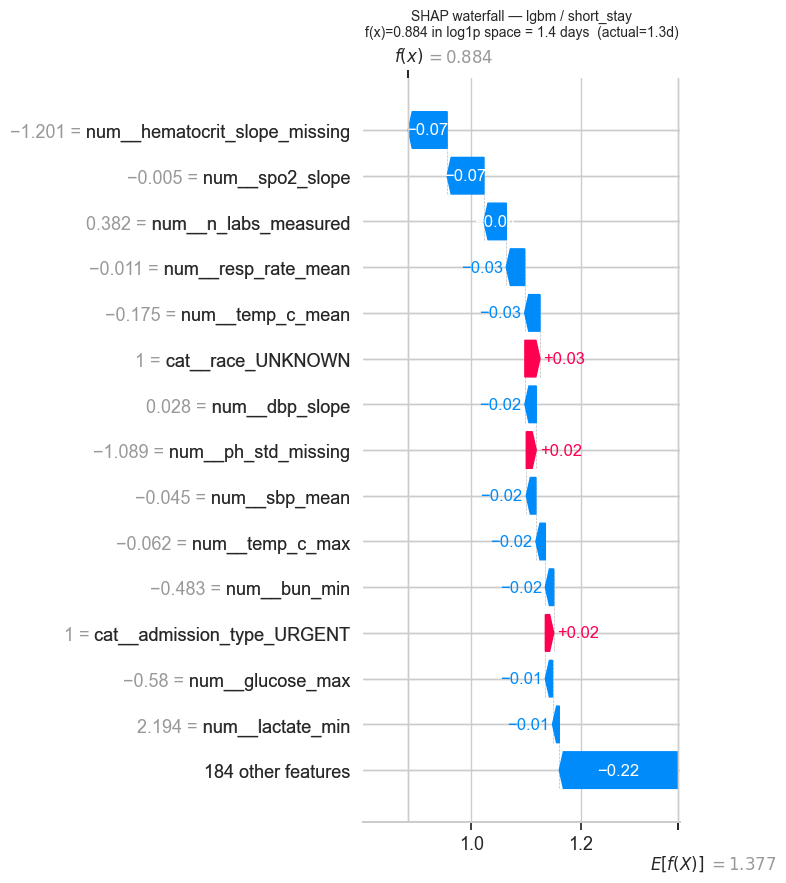


--- long_stay ---


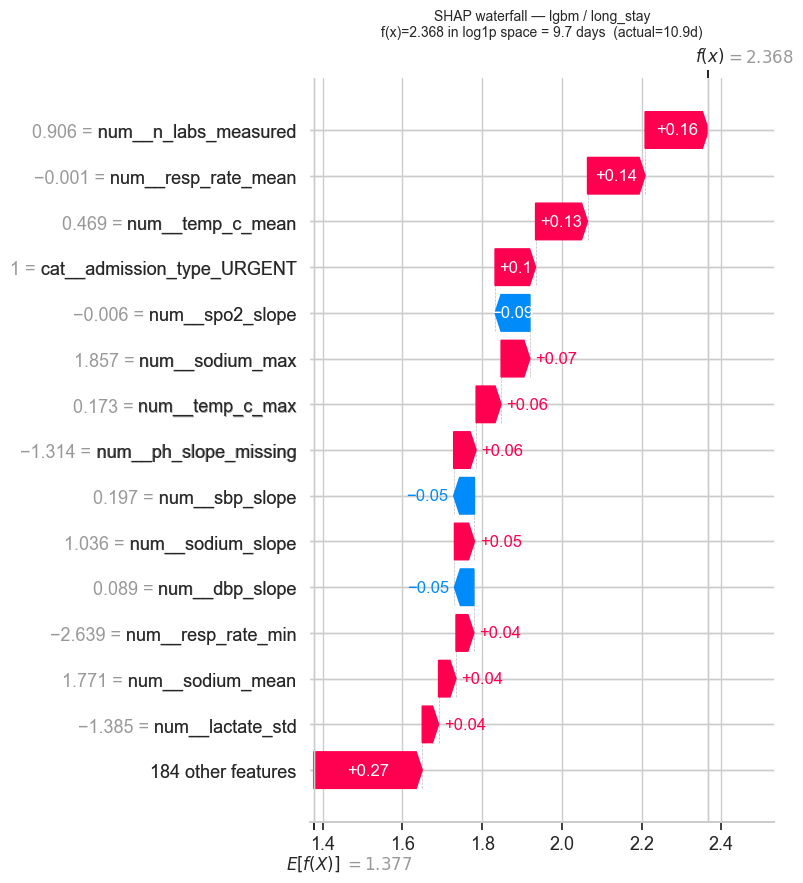

In [10]:
for label, idx in EXAMPLE_IDX.items():
    print(f"\n--- {label} ---")
    shap_waterfall("lgbm", pipes["lgbm"], X_te_trans, feature_names, idx, label)

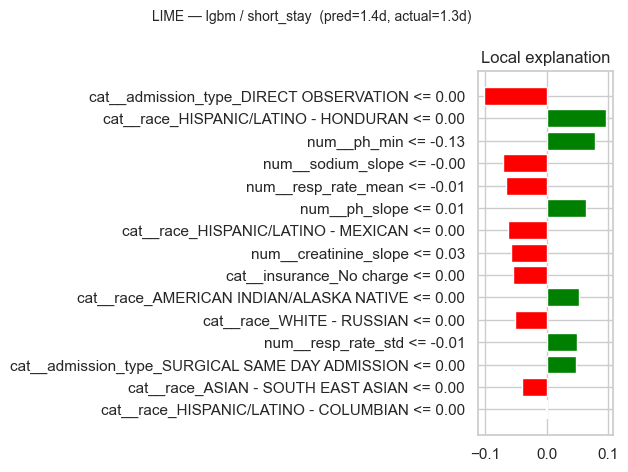

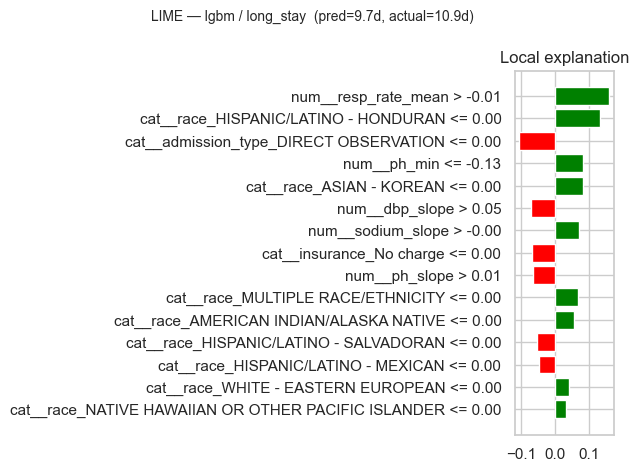

  LIME lgbm: 50/200


  LIME lgbm: 100/200


  LIME lgbm: 150/200


  LIME lgbm: 200/200
  LIME lgbm: done (200 samples)


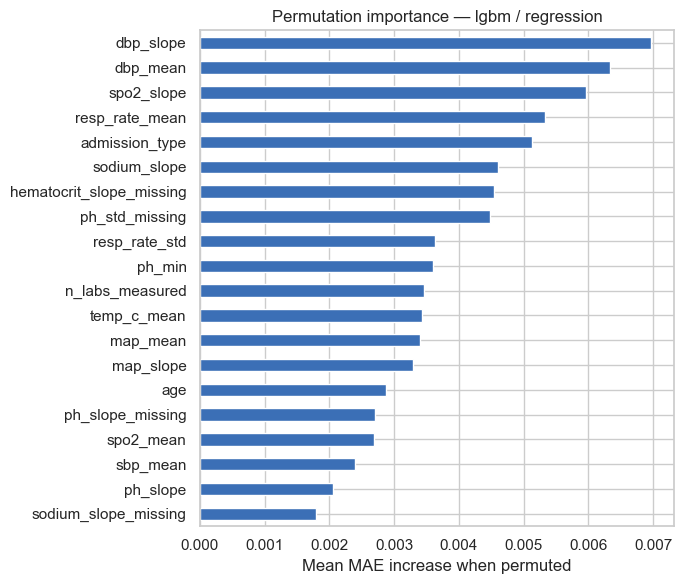

In [11]:
# LIME local for 3 patients
for label, idx in EXAMPLE_IDX.items():
    lime_explain("lgbm", pipes["lgbm"], X_tr_trans, X_te_trans, feature_names, idx, label)

# LIME global
lgbm_lime_imp = lime_global("lgbm", pipes["lgbm"], X_tr_trans, X_te_trans, feature_names)

# Permutation importance
lgbm_perm_imp = perm_importance("lgbm", pipes["lgbm"], X_te, y_te)

## 3. Random Forest

Fundamentally different architecture: bagging (many independent trees averaged) vs boosting (sequential correction). If RF's top features match XGB/LGBM, the signal is truly in the data, not an artifact of the learning algorithm.

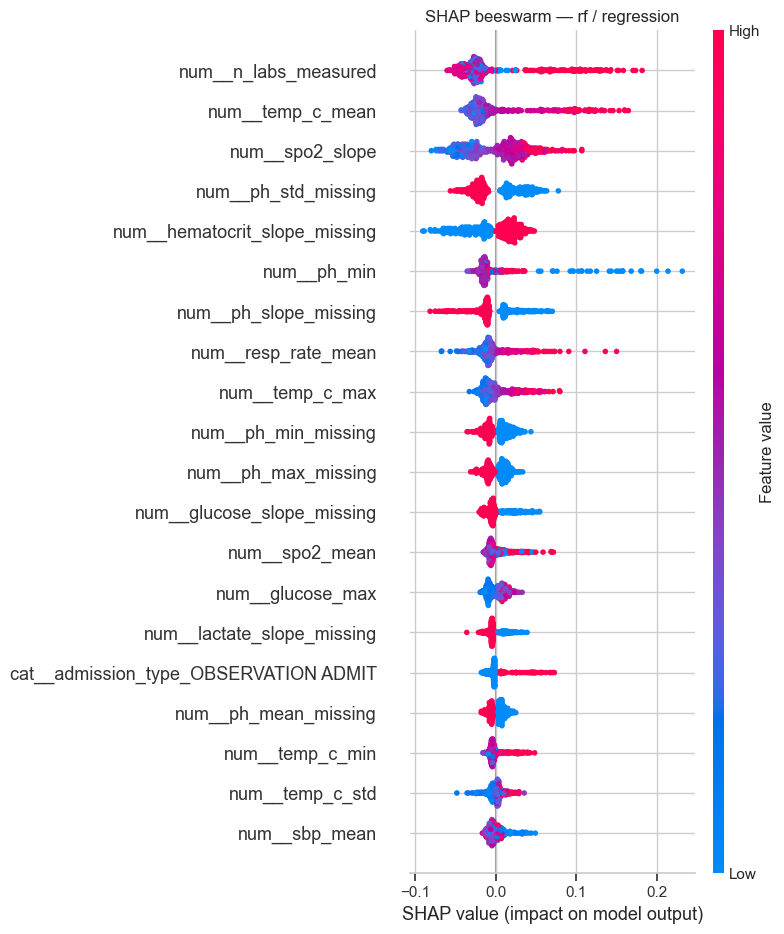


Top 10 features by mean |SHAP|:
num__n_labs_measured             0.040787
num__temp_c_mean                 0.033141
num__spo2_slope                  0.032645
num__ph_std_missing              0.025539
num__hematocrit_slope_missing    0.024796
num__ph_min                      0.020279
num__ph_slope_missing            0.019582
num__resp_rate_mean              0.015956
num__temp_c_max                  0.014417
num__ph_min_missing              0.012448


In [12]:
rf_sv, rf_shap_imp = shap_global("rf", pipes["rf"], X_te_trans, feature_names)
print("\nTop 10 features by mean |SHAP|:")
print(rf_shap_imp.head(10).to_string())


--- short_stay ---


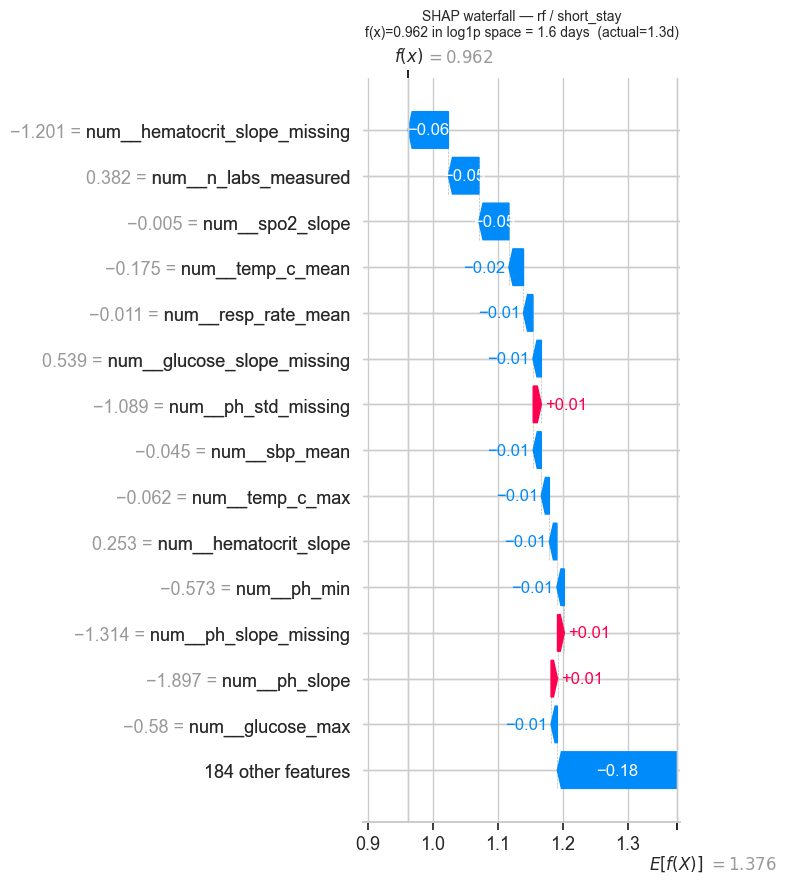


--- long_stay ---


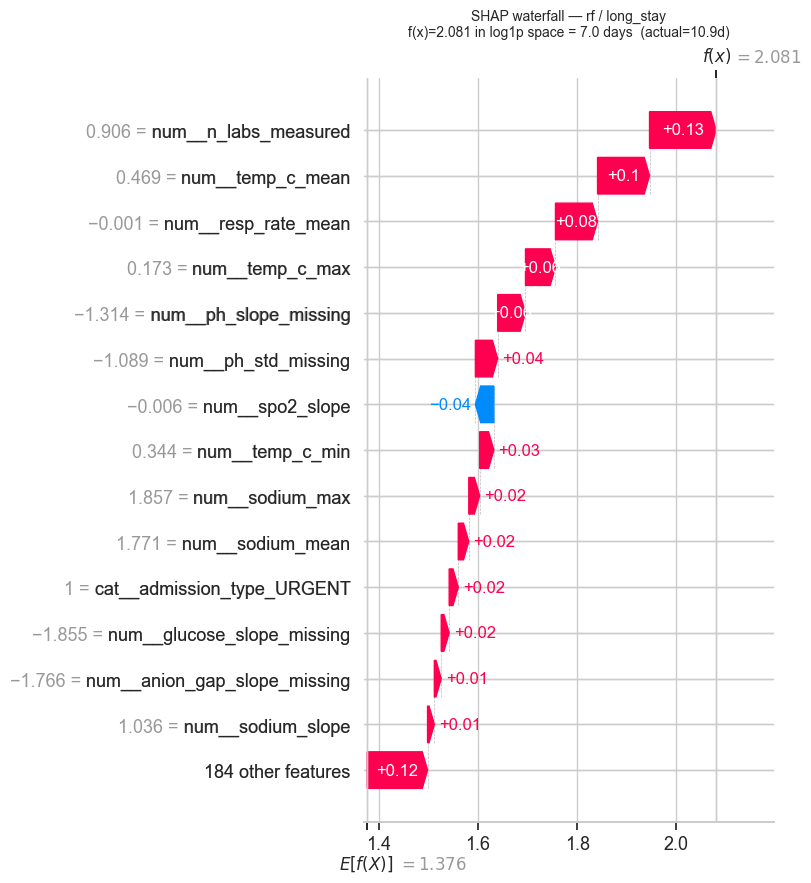

In [13]:
for label, idx in EXAMPLE_IDX.items():
    print(f"\n--- {label} ---")
    shap_waterfall("rf", pipes["rf"], X_te_trans, feature_names, idx, label)

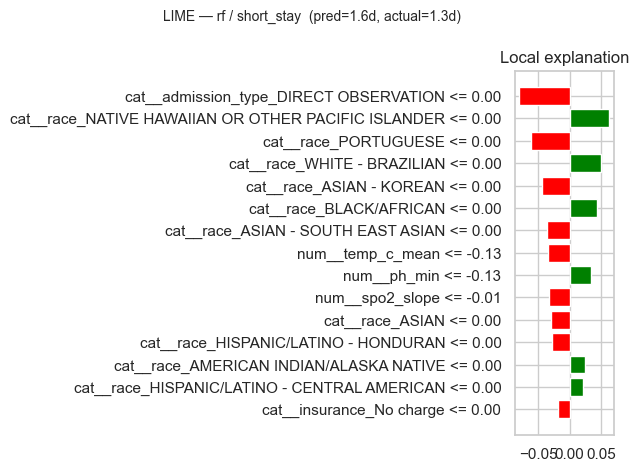

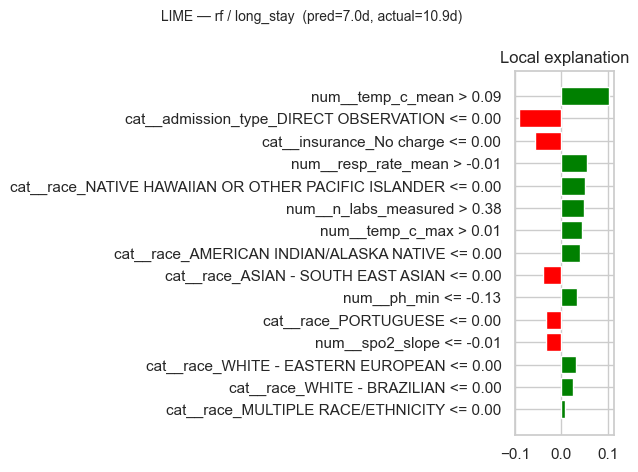

  LIME rf: 50/200


  LIME rf: 100/200


  LIME rf: 150/200


  LIME rf: 200/200
  LIME rf: done (200 samples)


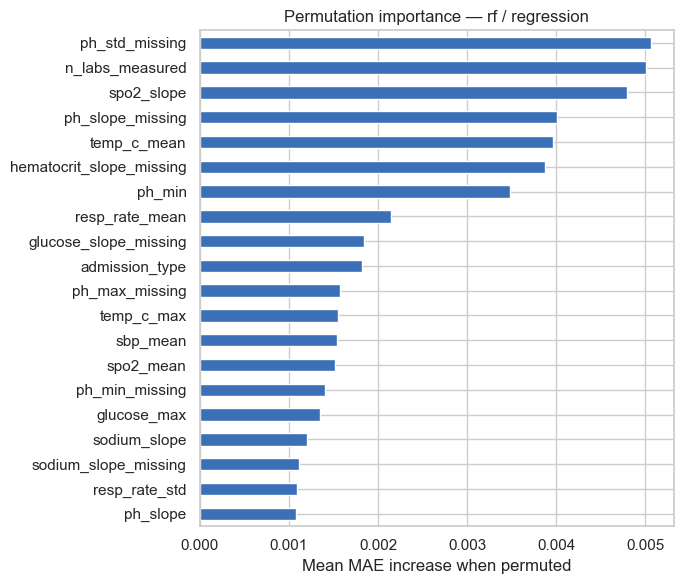

In [14]:
for label, idx in EXAMPLE_IDX.items():
    lime_explain("rf", pipes["rf"], X_tr_trans, X_te_trans, feature_names, idx, label)

rf_lime_imp = lime_global("rf", pipes["rf"], X_tr_trans, X_te_trans, feature_names)
rf_perm_imp = perm_importance("rf", pipes["rf"], X_te, y_te)

## 4. Linear (Ridge)

The interpretable baseline. For a linear model, the standardized coefficients directly show feature importance — no SHAP needed. A large positive coefficient means "this feature increases predicted LoS"; negative means "decreases." LIME and permutation importance still apply for cross-method comparison.

Key question: does the linear model rely on the same features as tree models, or does it find a different signal?

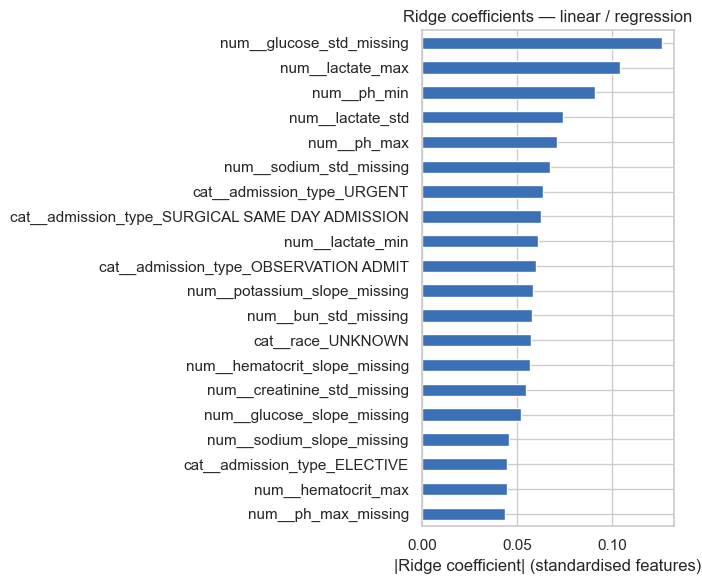

Top 10 features by |coefficient|:
num__glucose_std_missing                           0.126121
num__lactate_max                                   0.104199
num__ph_min                                        0.091002
num__lactate_std                                   0.073825
num__ph_max                                        0.070776
num__sodium_std_missing                            0.067040
cat__admission_type_URGENT                         0.063431
cat__admission_type_SURGICAL SAME DAY ADMISSION    0.062469
num__lactate_min                                   0.060839
cat__admission_type_OBSERVATION ADMIT              0.059847


In [15]:
# ── Linear: Ridge coefficients as feature importance ──
lin_model = pipes["linear"].named_steps["model"]
lin_coef = pd.Series(np.abs(lin_model.coef_), index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
lin_coef.head(20)[::-1].plot.barh(ax=ax, color="#3b6fb6")
ax.set_xlabel("|Ridge coefficient| (standardised features)")
ax.set_title(f"Ridge coefficients — linear / {TASK}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"ridge_coef_{TASK}_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top 10 features by |coefficient|:")
print(lin_coef.head(10).to_string())

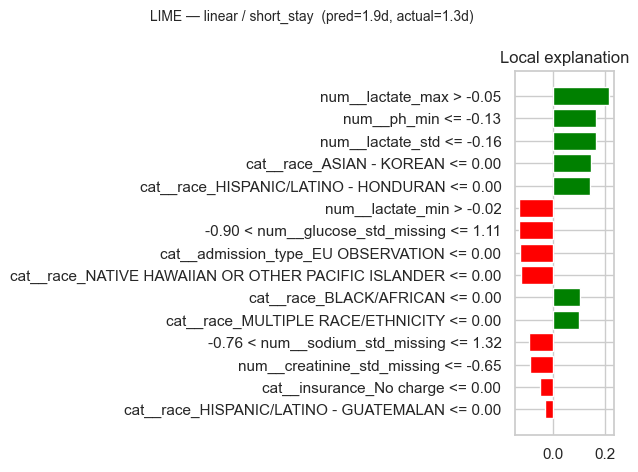

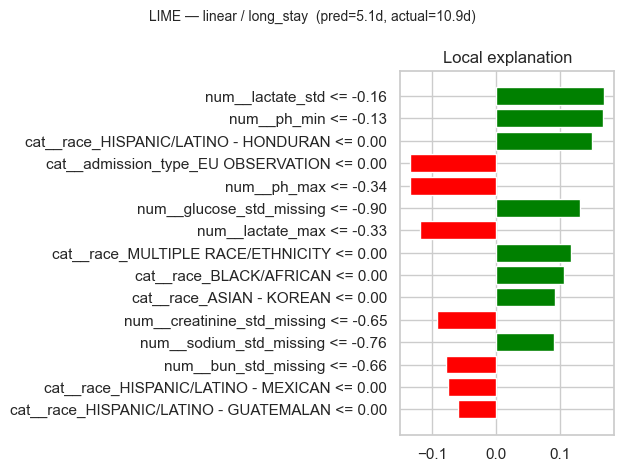

  LIME linear: 50/200


  LIME linear: 100/200


  LIME linear: 150/200


  LIME linear: 200/200
  LIME linear: done (200 samples)


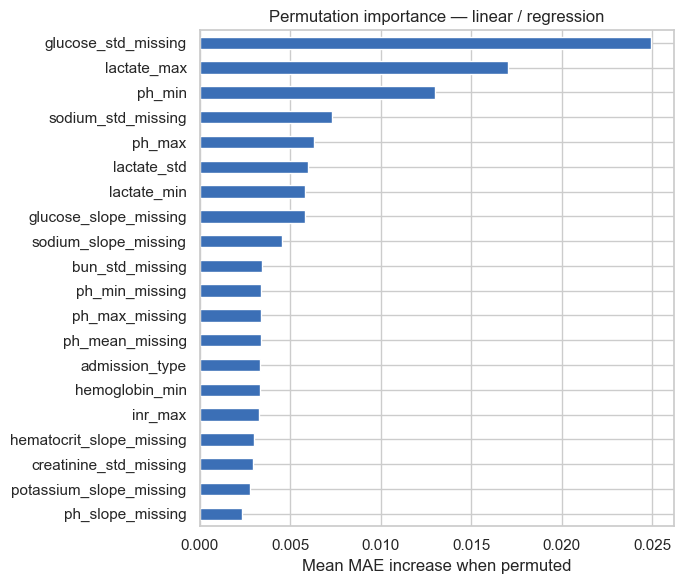

In [16]:
for label, idx in EXAMPLE_IDX.items():
    lime_explain("linear", pipes["linear"], X_tr_trans, X_te_trans, feature_names, idx, label)

lin_lime_imp = lime_global("linear", pipes["linear"], X_tr_trans, X_te_trans, feature_names)
lin_perm_imp = perm_importance("linear", pipes["linear"], X_te, y_te)

## 5. Cross-method agreement

**The core thesis question:** do SHAP, LIME, and permutation importance agree on which features drive ICU length of stay?

Two metrics measure this:

1. **Top-10 overlap** — For each pair of methods, how many of their top-10 most important features are the same? Score: X/10. Higher = more agreement.
2. **Spearman rank correlation** — Instead of just top-10, compares the full ranking of all features between methods. Score: 0 to 1 (1 = identical rankings). The heatmap below shows all pairwise correlations.

**How to interpret:** If SHAP and permutation agree (8/10 overlap), it means the model's internal logic (SHAP) and its observed behavior (permutation) point to the same features — strong evidence that those features genuinely matter.

In [17]:
from scipy.stats import spearmanr

# Normalize all rankings to raw column names (strip num__/cat__ prefixes,
# aggregate OHE dummies back to base categorical column)
norm_rankings = {
    "xgb_shap": normalize_imp(xgb_shap_imp), "xgb_lime": normalize_imp(xgb_lime_imp), "xgb_perm": normalize_imp(xgb_perm_imp),
    "lgbm_shap": normalize_imp(lgbm_shap_imp), "lgbm_lime": normalize_imp(lgbm_lime_imp), "lgbm_perm": normalize_imp(lgbm_perm_imp),
    "rf_shap": normalize_imp(rf_shap_imp), "rf_lime": normalize_imp(rf_lime_imp), "rf_perm": normalize_imp(rf_perm_imp),
    "lin_coef": normalize_imp(lin_coef), "lin_lime": normalize_imp(lin_lime_imp), "lin_perm": normalize_imp(lin_perm_imp),
}

# ── Top-10 overlap within each model (SHAP vs LIME vs Perm) ──
print("Top-10 feature overlap (count out of 10):\n")
for model_tag in ["xgb", "lgbm", "rf"]:
    s10 = set(norm_rankings[f"{model_tag}_shap"].head(10).index)
    l10 = set(norm_rankings[f"{model_tag}_lime"].head(10).index)
    p10 = set(norm_rankings[f"{model_tag}_perm"].head(10).index)
    print(f"  {model_tag.upper():>5s}:  SHAP-LIME {len(s10 & l10)}/10  |  SHAP-Perm {len(s10 & p10)}/10  |  LIME-Perm {len(l10 & p10)}/10")

s10 = set(norm_rankings["lin_coef"].head(10).index)
l10 = set(norm_rankings["lin_lime"].head(10).index)
p10 = set(norm_rankings["lin_perm"].head(10).index)
print(f"  {'LIN':>5s}:  Coef-LIME {len(s10 & l10)}/10  |  Coef-Perm {len(s10 & p10)}/10  |  LIME-Perm {len(l10 & p10)}/10")

Top-10 feature overlap (count out of 10):

    XGB:  SHAP-LIME 6/10  |  SHAP-Perm 8/10  |  LIME-Perm 5/10
   LGBM:  SHAP-LIME 5/10  |  SHAP-Perm 7/10  |  LIME-Perm 3/10
     RF:  SHAP-LIME 6/10  |  SHAP-Perm 9/10  |  LIME-Perm 5/10
    LIN:  Coef-LIME 3/10  |  Coef-Perm 7/10  |  LIME-Perm 1/10


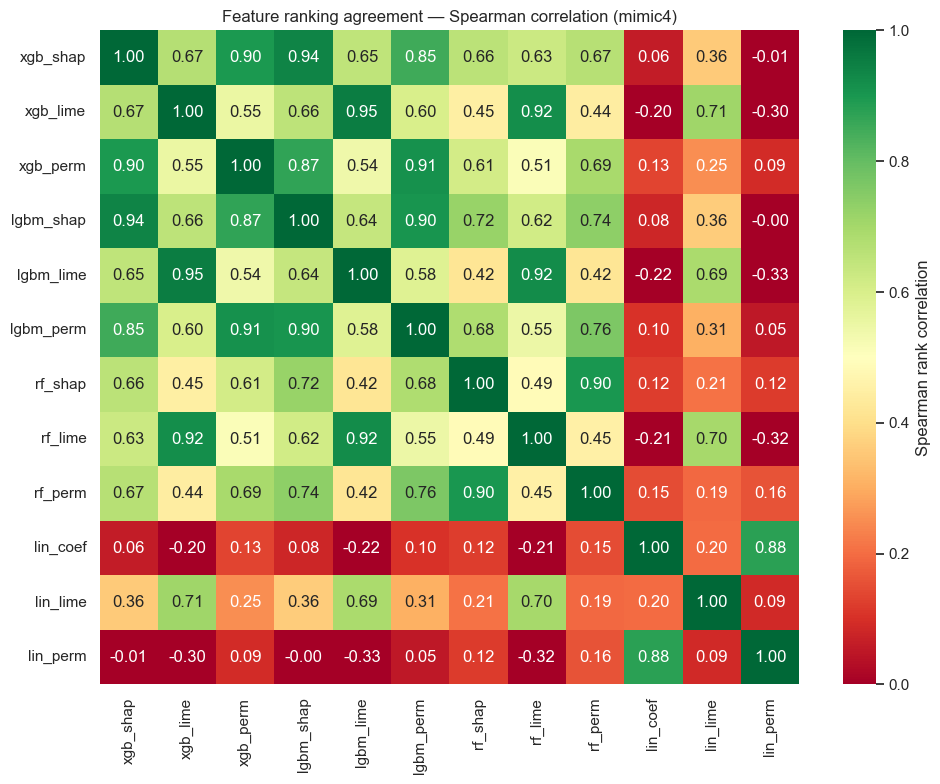

In [18]:
# ── Spearman rank correlation heatmap across all methods ──
# Align all normalized rankings to the same feature set
all_raw_feats = sorted(set().union(*[set(v.index) for v in norm_rankings.values()]))
rank_df = pd.DataFrame(index=all_raw_feats)
for name, imp in norm_rankings.items():
    rank_df[name] = imp.reindex(all_raw_feats).fillna(0).rank(ascending=False)

corr_matrix = rank_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
            vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Spearman rank correlation"})
ax.set_title(f"Feature ranking agreement — Spearman correlation ({SOURCE})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"xai_spearman_heatmap_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Classification task XAI

Same SHAP + permutation analysis but for the **binary classifier** (short stay <7 days vs long stay >=7 days) instead of continuous regression.

**Key question:** Do the same features predict "how many days" and "short vs long"? High overlap would mean the underlying clinical signal is the same regardless of how we frame the prediction problem.

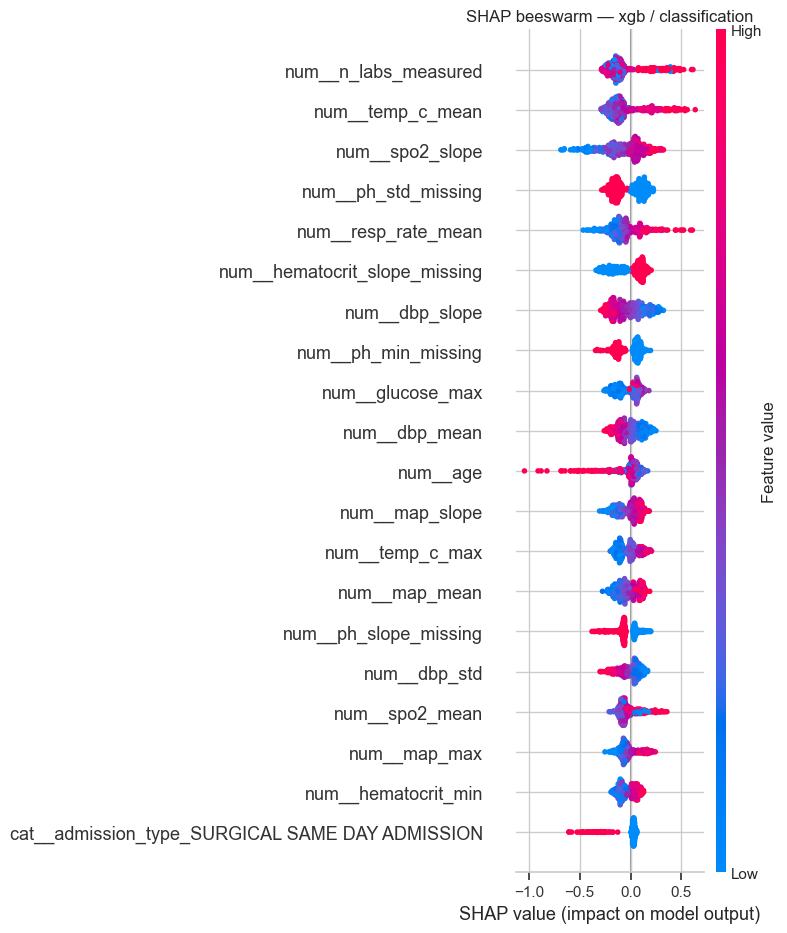

Top 10 classification features by mean |SHAP|:
num__n_labs_measured             0.178137
num__temp_c_mean                 0.165715
num__spo2_slope                  0.152012
num__ph_std_missing              0.134343
num__resp_rate_mean              0.128740
num__hematocrit_slope_missing    0.127874
num__dbp_slope                   0.127654
num__ph_min_missing              0.100162
num__glucose_max                 0.093650
num__dbp_mean                    0.091824


In [19]:
# Load XGB classifier
clf_pipe = joblib.load(MODELS_DIR / f"xgb_classification_{SOURCE}.joblib")
y_clf = prepare_target(y_raw, "classification")
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_SEED, stratify=y_clf,
)
X_te_c_trans = clf_pipe.named_steps["preprocess"].transform(X_te_c)

clf_estimator = clf_pipe.named_steps["model"]
clf_explainer = shap.TreeExplainer(clf_estimator)
rng = np.random.RandomState(SEED)
idx_c = rng.choice(len(X_te_c_trans), size=min(N_SHAP, len(X_te_c_trans)), replace=False)
clf_sv = clf_explainer(X_te_c_trans[idx_c])
clf_sv.feature_names = feature_names

shap.summary_plot(clf_sv, X_te_c_trans[idx_c], feature_names=feature_names, show=False, max_display=20)
plt.title(f"SHAP beeswarm — xgb / classification")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_beeswarm_xgb_classification_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

clf_shap_imp = pd.Series(np.abs(clf_sv.values).mean(axis=0), index=feature_names).sort_values(ascending=False)
print("Top 10 classification features by mean |SHAP|:")
print(clf_shap_imp.head(10).to_string())

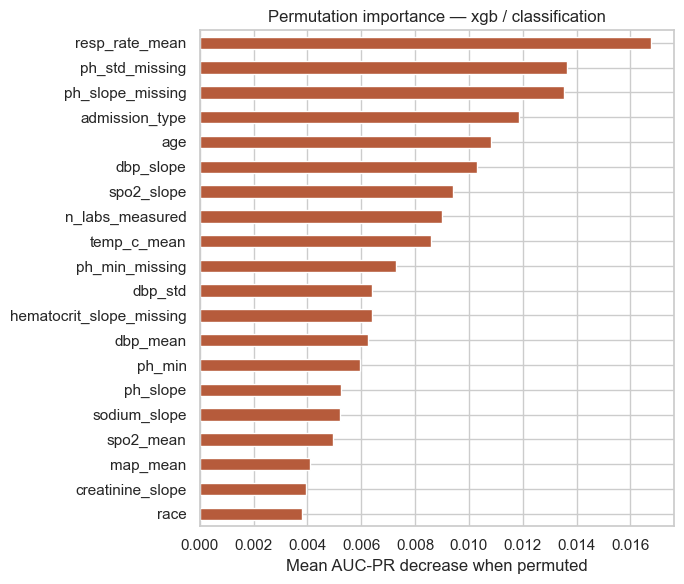


XGB Regression vs Classification SHAP top-10 overlap: 7/10
Shared features: {'resp_rate_mean', 'hematocrit_slope_missing', 'temp_c_mean', 'admission_type', 'spo2_slope', 'n_labs_measured', 'dbp_slope'}


In [20]:
# Permutation importance for classifier
clf_perm = permutation_importance(
    clf_pipe, X_te_c, y_te_c, n_repeats=10,
    random_state=SEED, scoring="average_precision", n_jobs=-1,
)
clf_perm_imp = pd.Series(clf_perm.importances_mean, index=X_te_c.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
clf_perm_imp.head(20)[::-1].plot.barh(ax=ax, color="#b65b3b")
ax.set_xlabel("Mean AUC-PR decrease when permuted")
ax.set_title(f"Permutation importance — xgb / classification")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"perm_importance_xgb_classification_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

# Regression vs Classification SHAP top-10 overlap (normalized names)
reg_norm = normalize_imp(xgb_shap_imp)
clf_norm = normalize_imp(clf_shap_imp)
reg_top10 = set(reg_norm.head(10).index)
clf_top10 = set(clf_norm.head(10).index)
print(f"\nXGB Regression vs Classification SHAP top-10 overlap: {len(reg_top10 & clf_top10)}/10")
print(f"Shared features: {reg_top10 & clf_top10}")

## 7. Clinical alignment with literature

**Final validation:** Do our top features make clinical sense, and do they match what published ICU LoS studies found?

The table below shows the top-10 features per model per method, using **normalized names** (no `num__`/`cat__` prefixes, OHE dummies aggregated back to base columns).

**Expected clinically important features** (from literature):
- **Vital instability:** respiratory rate, blood pressure trends, SpO2 changes (Hempel et al. 2023)
- **Lab markers:** lactate (tissue hypoperfusion), creatinine (renal function), pH (acid-base) (Hempel, Chiba)
- **Measurement intensity:** number of labs ordered correlates with clinical suspicion of severity

**Our novel finding:** `n_labs_measured` (how many different lab tests were ordered in the first 24h) appears as a top-5 SHAP feature across all tree models — measurement intensity as an acuity proxy has not been explicitly reported in prior ICU LoS literature.

In [21]:
# ── Summary: top-10 features across all models and methods (normalized names) ──
summary_rows = []
for model_tag, shap_key, lime_key, perm_key in [
    ("XGB", "xgb_shap", "xgb_lime", "xgb_perm"),
    ("LGBM", "lgbm_shap", "lgbm_lime", "lgbm_perm"),
    ("RF", "rf_shap", "rf_lime", "rf_perm"),
    ("Linear", "lin_coef", "lin_lime", "lin_perm"),
]:
    s = norm_rankings[shap_key]
    l = norm_rankings[lime_key]
    p = norm_rankings[perm_key]
    for rank in range(10):
        summary_rows.append({
            "model": model_tag,
            "rank": rank + 1,
            "SHAP/Coef": s.index[rank] if rank < len(s) else "",
            "LIME": l.index[rank] if rank < len(l) else "",
            "Permutation": p.index[rank] if rank < len(p) else "",
        })

summary_df = pd.DataFrame(summary_rows)
for model_tag in ["XGB", "LGBM", "RF", "Linear"]:
    print(f"\n{'='*60}")
    print(f"  {model_tag} — Top-10 features per method")
    print(f"{'='*60}")
    sub = summary_df[summary_df["model"] == model_tag][["rank", "SHAP/Coef", "LIME", "Permutation"]]
    display(sub.set_index("rank"))

summary_df.to_csv(FIGURES_DIR.parent / "tables" / f"xai_top10_summary_{SOURCE}.csv", index=False)
print(f"\nSaved to reports/tables/xai_top10_summary_{SOURCE}.csv")


  XGB — Top-10 features per method


,SHAP/Coef,LIME,Permutation
rank,,,
1,admission_type,race,dbp_slope
2,spo2_slope,admission_type,dbp_mean
3,dbp_slope,insurance,spo2_slope
4,n_labs_measured,resp_rate_mean,hematocrit_slope_missing
5,temp_c_mean,dbp_slope,resp_rate_mean
6,hematocrit_slope_missing,spo2_slope,admission_type
7,resp_rate_mean,temp_c_mean,sodium_slope
8,map_slope,map_min,map_slope
9,dbp_mean,ph_slope,ph_slope_missing



  LGBM — Top-10 features per method


,SHAP/Coef,LIME,Permutation
rank,,,
1,admission_type,race,dbp_slope
2,spo2_slope,admission_type,dbp_mean
3,n_labs_measured,insurance,spo2_slope
4,temp_c_mean,resp_rate_mean,resp_rate_mean
5,dbp_slope,dbp_slope,admission_type
6,resp_rate_mean,map_min,sodium_slope
7,hematocrit_slope_missing,spo2_mean,hematocrit_slope_missing
8,ph_std_missing,map_slope,ph_std_missing
9,map_slope,map_max,resp_rate_std



  RF — Top-10 features per method


,SHAP/Coef,LIME,Permutation
rank,,,
1,n_labs_measured,race,ph_std_missing
2,temp_c_mean,admission_type,n_labs_measured
3,spo2_slope,temp_c_mean,spo2_slope
4,ph_std_missing,insurance,ph_slope_missing
5,hematocrit_slope_missing,spo2_mean,temp_c_mean
6,ph_min,resp_rate_mean,hematocrit_slope_missing
7,ph_slope_missing,spo2_slope,ph_min
8,resp_rate_mean,n_labs_measured,resp_rate_mean
9,temp_c_max,map_min,glucose_slope_missing



  Linear — Top-10 features per method


,SHAP/Coef,LIME,Permutation
rank,,,
1,admission_type,race,glucose_std_missing
2,race,admission_type,lactate_max
3,glucose_std_missing,insurance,ph_min
4,lactate_max,hematocrit_max,sodium_std_missing
5,ph_min,hemoglobin_min,ph_max
6,lactate_std,n_labs_measured,lactate_std
7,ph_max,heart_rate_mean,lactate_min
8,sodium_std_missing,ph_min,glucose_slope_missing
9,lactate_min,creatinine_std,sodium_slope_missing



Saved to reports/tables/xai_top10_summary_mimic4.csv


## 8. Feature group analysis

Instead of looking at 152 individual features, group them by **clinical category** and compare total SHAP contribution per group. This answers: "Does the model rely more on vital signs, lab values, or missing-indicator signals?"

**Feature groups:**
- **Vital values** — min/max/mean/std of heart rate, BP, respiratory rate, SpO2, temperature
- **Vital slopes** — first-24h trends of vital signs (slope features)
- **Lab values** — min/max/mean/std of 14 lab tests
- **Lab slopes** — first-24h trends of lab values
- **Missing indicators** — binary flags for whether a measurement was taken
- **Measurement counts** — `n_vitals_measured`, `n_labs_measured`
- **Demographics** — age, gender, admission type, race, insurance

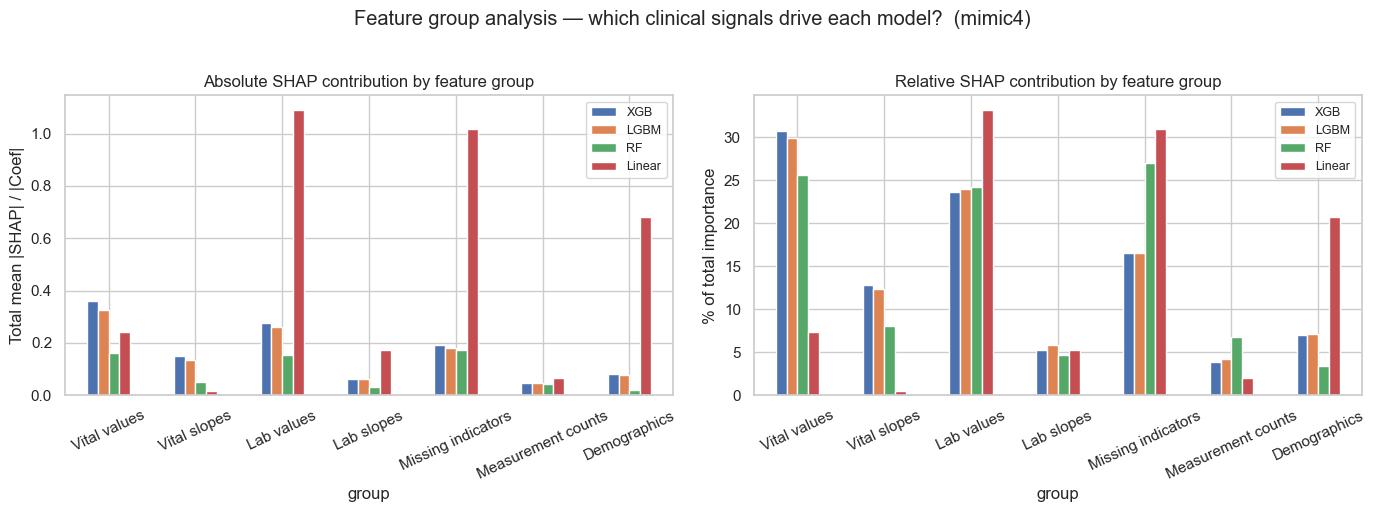


Feature group importance (% of total):

model               LGBM  Linear    RF   XGB
group                                       
Vital values        29.9     7.3  25.6  30.8
Vital slopes        12.4     0.5   8.0  12.8
Lab values          24.0    33.2  24.3  23.6
Lab slopes           5.9     5.3   4.7   5.3
Missing indicators  16.5    31.0  27.1  16.6
Measurement counts   4.2     2.0   6.8   3.9
Demographics         7.2    20.7   3.4   7.1

Key insight: tree models rely on vital slopes + missing indicators,
while linear model relies on lab values + demographics.


In [22]:
# ── Classify each feature into a clinical group ──
from src.config import VITAL_ITEMIDS, LAB_ITEMIDS

vital_concepts = set(VITAL_ITEMIDS.keys())
lab_concepts = set(LAB_ITEMIDS.keys())

def classify_feature(fname):
    """Assign a normalized feature name to a clinical group."""
    if fname in ("n_vitals_measured", "n_labs_measured"):
        return "Measurement counts"
    if fname.endswith("_missing"):
        return "Missing indicators"
    if fname in ("age", "gender", "admission_type", "race", "insurance"):
        return "Demographics"
    base = fname.rsplit("_", 1)[0] if "_" in fname else fname
    agg = fname.rsplit("_", 1)[1] if "_" in fname else ""
    # Check if base concept is a vital or lab
    for vc in vital_concepts:
        if fname.startswith(vc):
            return "Vital slopes" if agg == "slope" else "Vital values"
    for lc in lab_concepts:
        if fname.startswith(lc):
            return "Lab slopes" if agg == "slope" else "Lab values"
    return "Other"

# Aggregate normalized SHAP importance by group, for each model
GROUP_ORDER = ["Vital values", "Vital slopes", "Lab values", "Lab slopes",
               "Missing indicators", "Measurement counts", "Demographics"]

group_data = []
for model_tag, shap_key in [("XGB", "xgb_shap"), ("LGBM", "lgbm_shap"),
                              ("RF", "rf_shap"), ("Linear", "lin_coef")]:
    imp = norm_rankings[shap_key]
    for fname, val in imp.items():
        grp = classify_feature(fname)
        group_data.append({"model": model_tag, "group": grp, "importance": val})

group_df = pd.DataFrame(group_data)
group_agg = group_df.groupby(["model", "group"])["importance"].sum().reset_index()
group_pivot = group_agg.pivot(index="group", columns="model", values="importance")
group_pivot = group_pivot.reindex(GROUP_ORDER).fillna(0)

# Normalize to percentages per model
group_pct = group_pivot.div(group_pivot.sum()) * 100

# ── Stacked bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Absolute SHAP contribution
group_pivot[["XGB", "LGBM", "RF", "Linear"]].plot.bar(ax=axes[0], rot=25)
axes[0].set_ylabel("Total mean |SHAP| / |Coef|")
axes[0].set_title("Absolute SHAP contribution by feature group")
axes[0].legend(fontsize=9)

# (b) Percentage
group_pct[["XGB", "LGBM", "RF", "Linear"]].plot.bar(ax=axes[1], rot=25)
axes[1].set_ylabel("% of total importance")
axes[1].set_title("Relative SHAP contribution by feature group")
axes[1].legend(fontsize=9)

fig.suptitle(f"Feature group analysis — which clinical signals drive each model?  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"feature_group_analysis_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

# Print summary table
print("\nFeature group importance (% of total):\n")
print(group_pct.round(1).to_string())
print(f"\nKey insight: tree models rely on vital slopes + missing indicators,")
print(f"while linear model relies on lab values + demographics.")